In [1]:
import pandas as pd

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
import time


df_raw = pd.read_csv('weather_data.csv')

df_raw

,time,city_group,station_name,lat,lon,air_temperature,highest_temperature,lowest_temperature,relative_humidity,wind_speed,maximum_wind_speed,minimum_wind_speed,wind_direction,precipitation_amount,maximum_precipitation_intensity,air_pressure,present_weather_(auto)
0,2026-01-31 14:00:00,Oulu,Oulu Airport,64.93,25.35,-20.0,-19.9,-20.1,81.0,3.1,3.6,2.6,151.0,NaN,NaN,1035.5,0.0
1,2026-01-31 15:00:00,Oulu,Oulu Airport,64.93,25.35,-20.2,-20.1,-20.4,81.0,2.9,3.4,2.6,151.0,NaN,NaN,1035.4,0.0
2,2026-01-31 16:00:00,Oulu,Oulu Airport,64.93,25.35,-20.3,-20.1,-20.6,81.0,3.2,3.4,2.9,150.0,NaN,NaN,1035.3,0.0
3,2026-01-31 17:00:00,Oulu,Oulu Airport,64.93,25.35,-19.8,-19.5,-20.3,81.0,3.0,3.4,2.8,153.0,NaN,NaN,1035.1,0.0
4,2026-01-31 18:00:00,Oulu,Oulu Airport,64.93,25.35,-19.8,-19.5,-20.0,81.0,3.1,3.5,2.7,150.0,NaN,NaN,1035.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16869,2025-12-31 09:00:00,Vaasa,Vaasa Airport,63.05,21.76,-6.8,-6.5,-7.3,94.0,1.1,1.5,0.6,32.0,NaN,NaN,1009.4,71.0
16870,2025-12-31 10:00:00,Vaasa,Vaasa Airport,63.05,21.76,-7.5,-6.9,-8.6,93.0,1.0,1.5,0.5,263.0,NaN,NaN,1009.1,71.0
16871,2025-12-31 11:00:00,Vaasa,Vaasa Airport,63.05,21.76,-9.2,-7.8,-10.9,93.0,0.8,1.3,0.5,208.0,NaN,NaN,1008.6,35.0
16872,2025-12-31 12:00:00,Vaasa,Vaasa Airport,63.05,21.76,-9.6,-7.8,-11.3,93.0,1.0,1.9,0.4,257.0,NaN,NaN,1008.2,20.0


In [2]:
df_raw.isnull().sum()

time                                  0
city_group                            0
station_name                          0
lat                                   0
lon                                   0
air_temperature                       2
highest_temperature                   0
lowest_temperature                    0
relative_humidity                     2
wind_speed                         2204
maximum_wind_speed                 2458
minimum_wind_speed                 2458
wind_direction                     2477
precipitation_amount               6330
maximum_precipitation_intensity    6340
air_pressure                          2
present_weather_(auto)             2153
dtype: int64

## Preprocessing


So we have a few of missing values, I will compensate for this in 2 ways:
- Use multiple centers in one city (and then we can merged the dataset later). I believe that the slight change in distance would not affect the data as a whole
- If there are still missing values, or lack of multiple reliable centers (**Oulu** centers does not have any `precipitation`) we will rely to `present_weather_(auto)` to help us. Since `present_weather_(auto)` give us the current weather status, we can try and deviate the `precipitation` out of this

In [3]:
df_raw['time'] = pd.to_datetime(df_raw['time'])

df_raw = df_raw.sort_values(['city_group', 'time'])
df_merged = df_raw.groupby(['city_group', 'time']).first().reset_index()

df_merged['present_weather_(auto)'].describe()


count    10502.000000
mean        30.424586
std         35.211940
min          0.000000
25%          0.000000
50%          0.000000
75%         71.000000
max         87.000000
Name: present_weather_(auto), dtype: float64

In [ ]:
# Define the 'Snow Codes'
snow_codes = [70, 71, 72, 73, 74, 75, 85, 86]
rain_codes = [60, 61, 62, 63, 64, 65, 80, 81]

# Logic: If precip is missing but we have a snow code, 
# fill with 0.1 (trace) to ensure the model knows 'something' fell.
mask_precip_nan = df_merged['precipitation_amount'].isna()

# Snow logic
df_merged.loc[mask_precip_nan & df_merged['present_weather_(auto)'].isin(snow_codes), 'precipitation_amount'] = 0.1

# Rain logic (just in case)
df_merged.loc[mask_precip_nan & df_merged['present_weather_(auto)'].isin(rain_codes), 'precipitation_amount'] = 0.1

# Final Fallback: Everything else becomes 0
df_merged['precipitation_amount'] = df_merged['precipitation_amount'].fillna(0.0)



## Interpolating

I have been researching to find the best stations across Finland's cities that would offer the best quality of data, but most of the observation center would either have missing features (`precipitation`, or `wind speed`).

So we retrieved multiple centers to compensate for this and merge them into cities. 

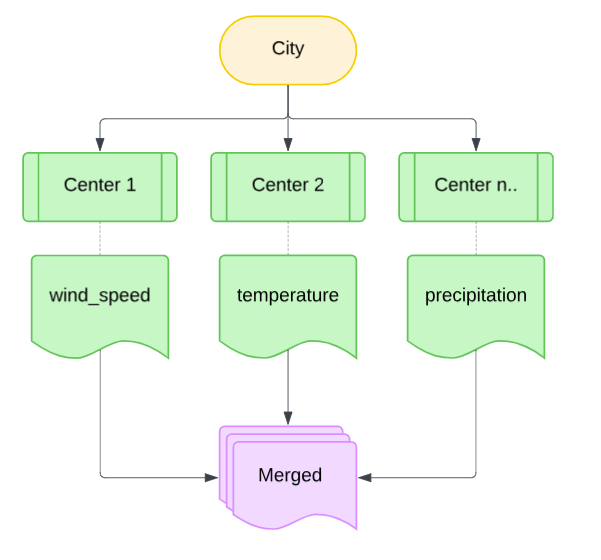



In [6]:
df_merged['wind_speed'] = df_merged.groupby('city_group')['wind_speed'].transform(lambda x: x.interpolate())
df_merged['maximum_wind_speed'] = df_merged.groupby('city_group')['maximum_wind_speed'].transform(lambda x: x.interpolate())
df_merged['minimum_wind_speed'] = df_merged.groupby('city_group')['minimum_wind_speed'].transform(lambda x: x.interpolate())

df_merged['wind_direction'] = df_merged.groupby('city_group')['wind_direction'].ffill()


df_merged['maximum_precipitation_intensity'] = df_merged['maximum_precipitation_intensity'].fillna(0.0)
df_merged['present_weather_(auto)'] = df_merged['present_weather_(auto)'].fillna(0)


df_merged.isnull().sum()

city_group                         0
time                               0
station_name                       0
lat                                0
lon                                0
air_temperature                    2
highest_temperature                0
lowest_temperature                 0
relative_humidity                  2
wind_speed                         0
maximum_wind_speed                 0
minimum_wind_speed                 0
wind_direction                     0
precipitation_amount               0
maximum_precipitation_intensity    0
air_pressure                       2
present_weather_(auto)             0
dtype: int64

Now the rest are very minor missing values so I will drop them

In [8]:
df_merged = df_merged.dropna()

Let's first look at some data for the last 7 days

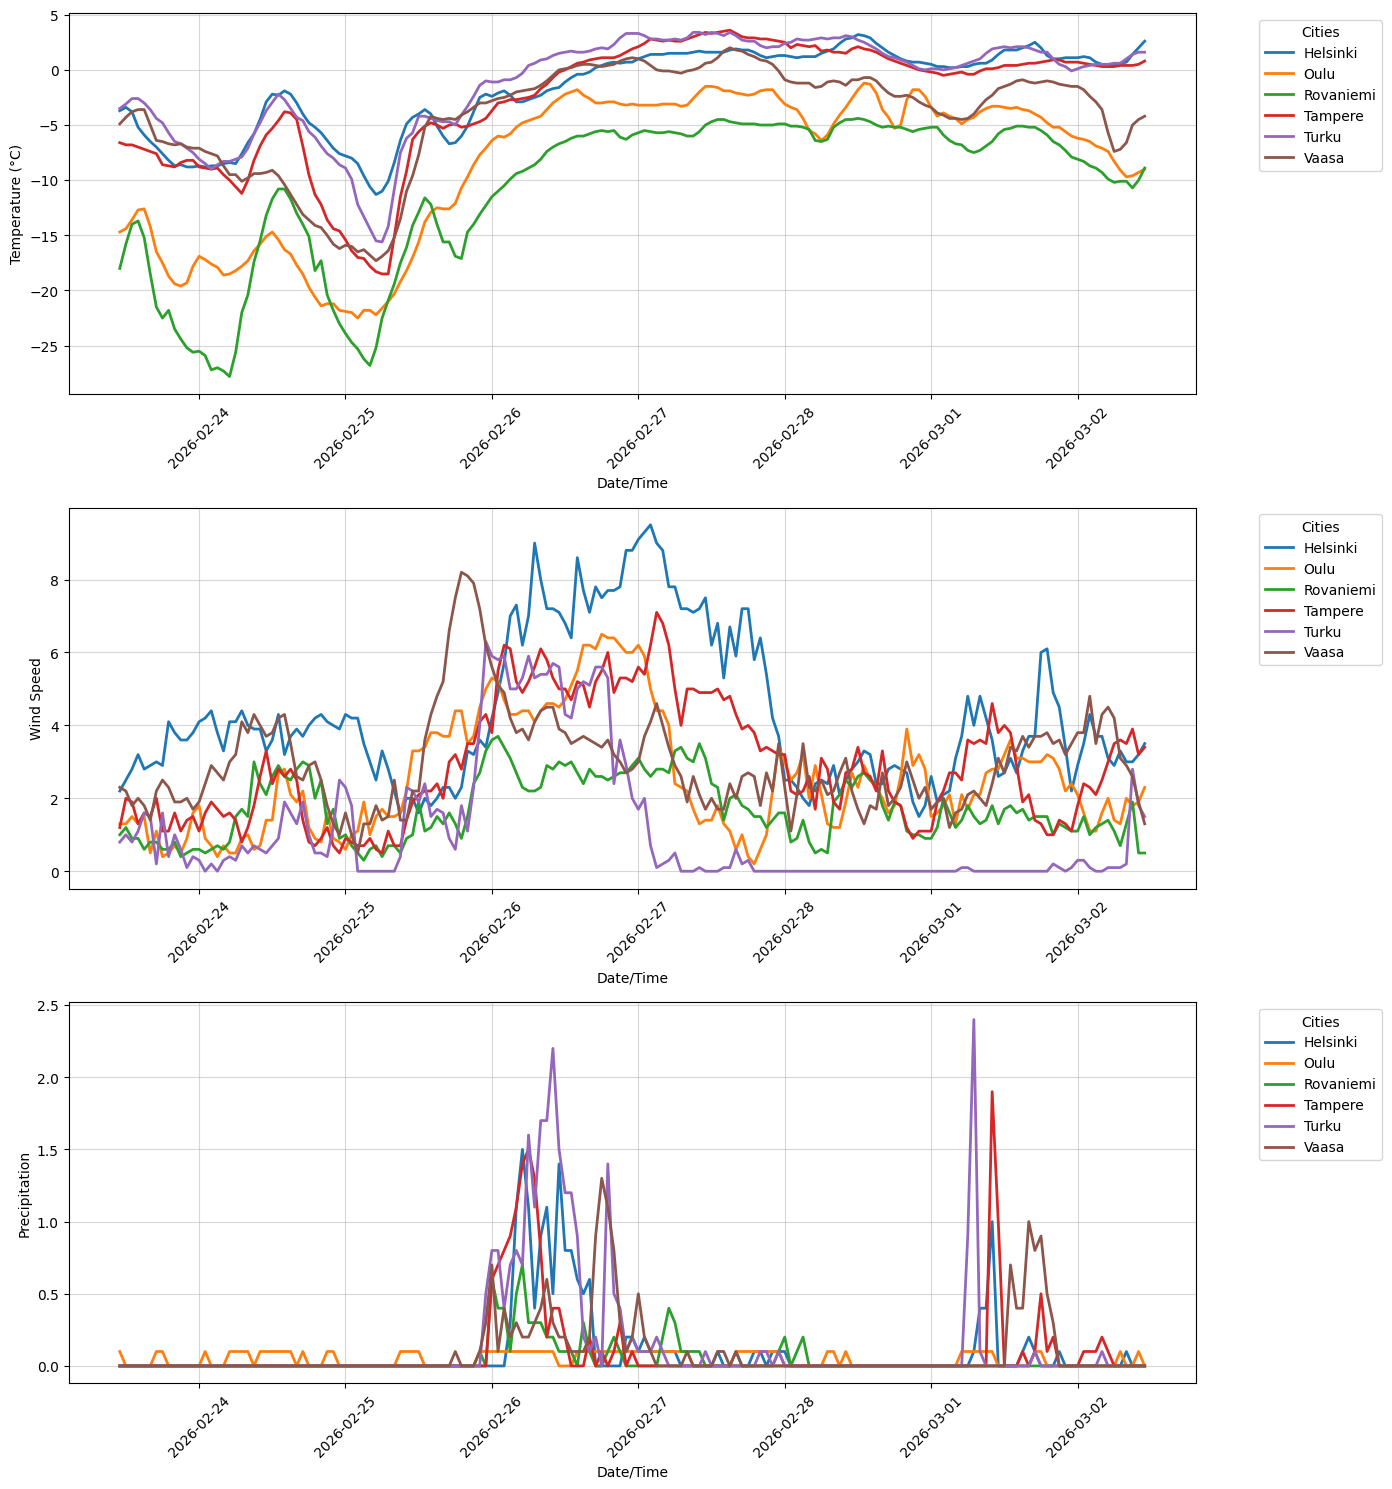

In [18]:
import matplotlib.pyplot as plt

# Filter for the last 7 days
last_date = df_merged['time'].max()
seven_days_ago = last_date - pd.Timedelta(days=7)
plot_df = df_merged[df_merged['time'] >= seven_days_ago].copy()

plt.figure(figsize= (14, 15))

plt.subplot(3, 1, 1)
# Loop through cities and plot
for city in plot_df['city_group'].unique():
    city_data = plot_df[plot_df['city_group'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['air_temperature'], label=city, linewidth=2)


plt.xlabel('Date/Time')
plt.ylabel('Temperature (°C)')
plt.legend(title="Cities", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.5)
plt.xticks(rotation=45)


plt.subplot(3, 1, 2)

for city in plot_df['city_group'].unique():
    city_data = plot_df[plot_df['city_group'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['wind_speed'], label=city, linewidth=2)

plt.xlabel('Date/Time')
plt.ylabel('Wind Speed')
plt.legend(title="Cities", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.5)
plt.xticks(rotation=45)

plt.subplot(3, 1, 3)

for city in plot_df['city_group'].unique():
    city_data = plot_df[plot_df['city_group'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['precipitation_amount'], label=city, linewidth=2)

plt.xlabel('Date/Time')
plt.ylabel('Precipitation')
plt.legend(title="Cities", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.5)
plt.xticks(rotation=45)


plt.tight_layout()